In [33]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [34]:
device=torch.device("Cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

In [35]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.1307,),
            std=(0.3081,),
        ),
    ]
)
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

In [36]:
train_dataset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

image shape: torch.Size([1, 28, 28])
label: 0


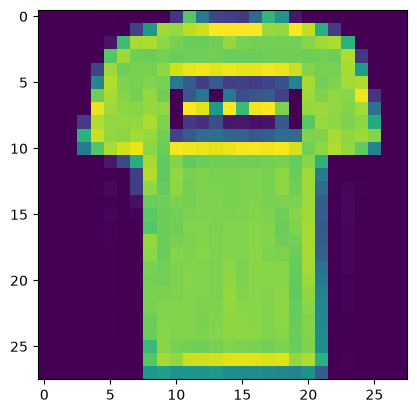

In [37]:
image,label=train_dataset[1]
print("image shape:",image.shape)
print("label:",label)
plt.imshow(image.squeeze())
plt.show()

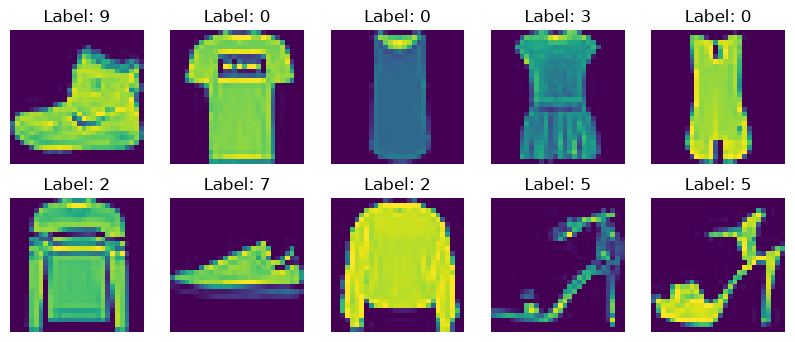

In [38]:
plt.figure(figsize=(10, 4))
for i in range(10):
    image, label = train_dataset[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze())
    plt.title(f"Label: {label}")
    plt.axis("off")

In [ ]:
input_size= 28 * 28
hidden_size= 128
# It means your hidden layer contains 128 neurons.
output_classes=10
batch_size=64
learning_rate=0.001
epochs=10
num_classes=10

In [40]:
#dataloader = generator 

train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle= False,
    
)   

In [ ]:
#nn.module inherit 
class MNISTCLassifer(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network=nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(input_size,hidden_size),
            nn.ReLU(),

# Keep positive values, turn negative values into 0.
            nn.Linear(hidden_size,num_classes)
        )
        
    def forward(self, x):
        return self.network(x)
    
model=MNISTCLassifer().to(device)
model
    

MNISTCLassifer(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [ ]:
criterion=nn.CrossEntropyLoss()
    #criterion is your loss function. in classification we measure through MSE but on deeplearning we do 
    # by crossentriopyloss

optimizer=optim.SGD(model.parameters(),lr=learning_rate)


    # CrossEntropyLoss tells the model how wrong it is; SGD tells the model how to change 
    # its weights to become less wrong.

In [43]:
for epoch in range(epochs):
    model.train()
    
    total_loss=0
    correct=0
    total=0
    
    for images, labels in train_loader:
        images=images.to(device)
        labels=labels.to(device)
        # Forward propagation calculates the model's guess,
        # while backpropagation calculates how to fix the errors.
        #forward propagation
        outputs=model(images)
        loss= criterion(outputs,labels)
        
        #backward propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss+=loss.item()
        _, predicted=torch.max(outputs,dim=1)
        total+=labels.size(0)
        correct+= (predicted==labels).sum().item()
    
    average_loss = total_loss / len(train_loader)
    training_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch + 1}/{epochs}], Loss: {average_loss:.4f}, Training Accuracy: {training_accuracy:.2f}%",
    )

Epoch [1/10], Loss: 1.3537, Training Accuracy: 60.18%
Epoch [2/10], Loss: 0.8451, Training Accuracy: 72.03%
Epoch [3/10], Loss: 0.7162, Training Accuracy: 76.24%
Epoch [4/10], Loss: 0.6471, Training Accuracy: 78.55%
Epoch [5/10], Loss: 0.6022, Training Accuracy: 79.97%
Epoch [6/10], Loss: 0.5712, Training Accuracy: 80.86%
Epoch [7/10], Loss: 0.5483, Training Accuracy: 81.39%
Epoch [8/10], Loss: 0.5306, Training Accuracy: 81.89%
Epoch [9/10], Loss: 0.5163, Training Accuracy: 82.28%
Epoch [10/10], Loss: 0.5047, Training Accuracy: 82.75%


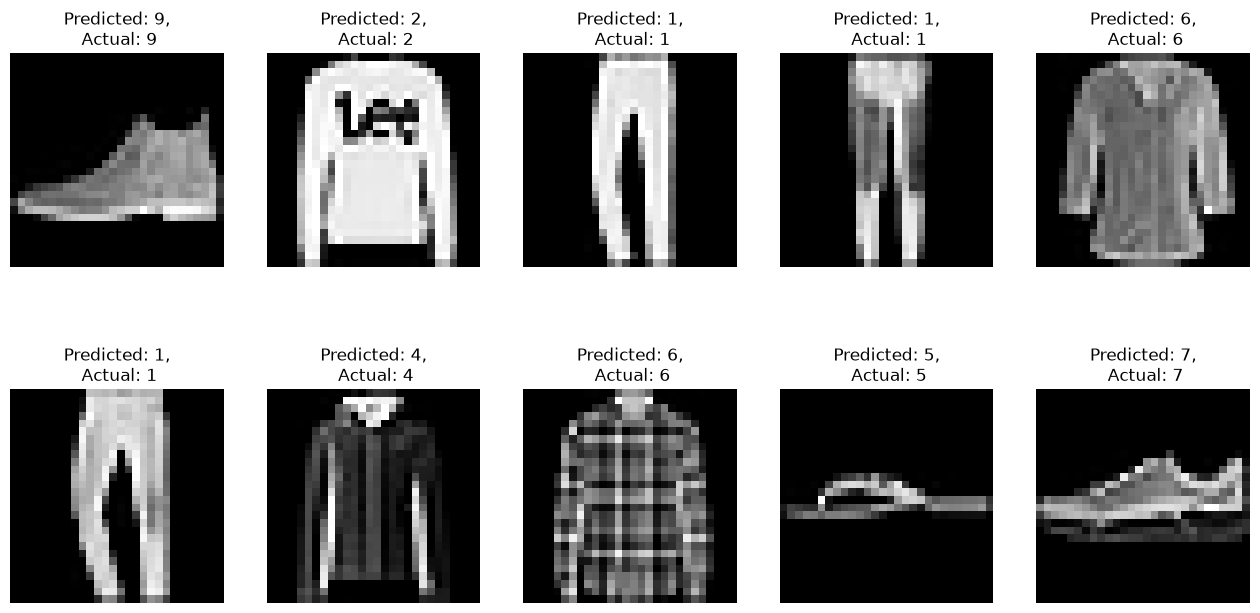

In [44]:
#81.60
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = outputs.argmax(dim=1)

images = images.cpu()
predictions = predictions.cpu()

plt.figure(figsize=(16, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Predicted: {predictions[i].item()},\n Actual: {labels[i].item()}")
    plt.axis("off")

torch.return_types.max(
values=tensor([11.1221], grad_fn=<MaxBackward0>),
indices=tensor([1]))


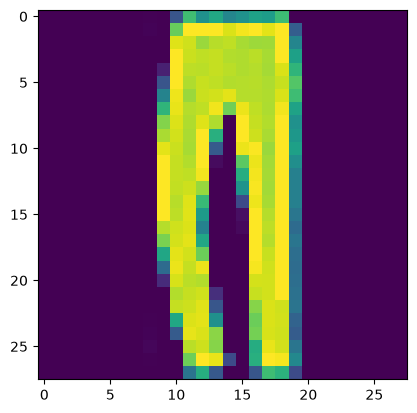

In [45]:
index=2

plt.imshow(images[index].squeeze())
pred= torch.max(model(images[index].to(device)),dim=1)
print(pred)

In [46]:
train_dataset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [47]:
test_dataset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']